<a href="https://colab.research.google.com/github/ayaaqais/Prediction-of-product-sales-/blob/main/prediction_of_product_sale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction of Product sales
- Author: Aya Khalil

## Project Overview
  In this project, we aim to predict product sales using data science.
We explore, clean, and analyze the dataset to understand patterns and trends.




## Load and Inspect Data


In [1]:
#Loading data
import pandas as pd
df = pd.read_csv('/content/sales_predictions_2023.csv')

df.head()


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


## Clean Data


In [3]:
# to get the number of rows and columns

df.shape

(8523, 12)

In [4]:
#the datatype of each column

df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


In [5]:
# to check duplicates we use the sum duplicated function

df.duplicated().sum()



np.int64(0)

In [6]:
# if we have duplicates we can drop them

df = df.drop_duplicates()

In [7]:
# to identify the missing value

df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [8]:
# so as we noticed there is missing values
# to fill them we use the mean for numbers and unknown for texts

for col in df.select_dtypes(include=['int64', 'float64']):
  df[col] = df[col].fillna(df[col].mean())

In [9]:
for col in df.select_dtypes(include=['object']):
  df[col] = df[col].fillna('Unkown')

In [10]:
# now we have to check if there is missing values or not

df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [11]:
# to fic the incosistent categories
# for example 'cat' 'Cat' 'cats'

for col in df.select_dtypes(include=['object']):
  df[col] = df[col].str.lower().str.strip()

In [12]:
df.describe()


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


## Exploratory Data Analysis


## Feature Inspection

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_theme(style="whitegrid")




Histogram Distribution of the Numeric features


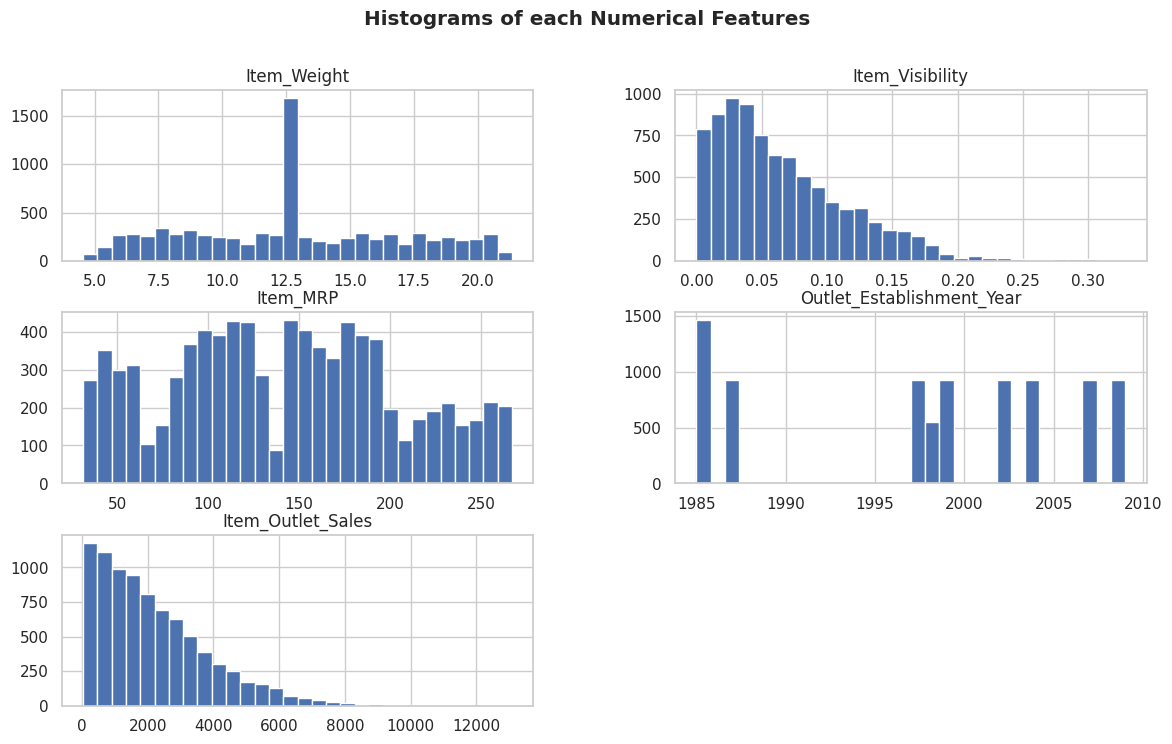

In [14]:
#array of columns we whant to use
# i put it in a variable so i can use it easily many times

numerical_cols = ["Item_Weight", "Item_Visibility", "Item_MRP", "Outlet_Establishment_Year", "Item_Outlet_Sales"]

df[numerical_cols].hist(bins=30, figsize=(14, 8))
plt.suptitle("Histograms of each Numerical Features", fontweight="bold")


plt.show()


### Boxplots (statistical summary of numerical features)


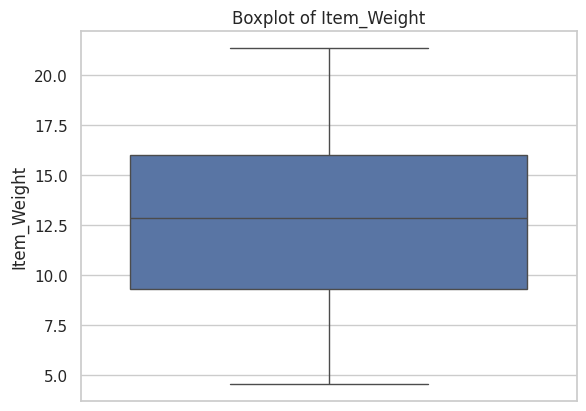

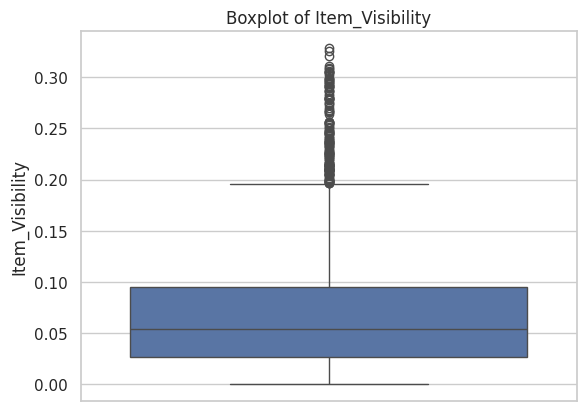

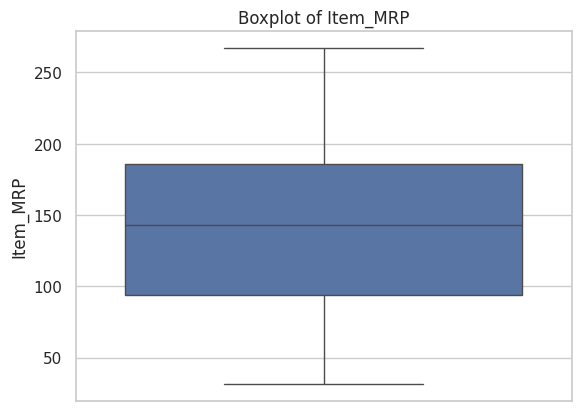

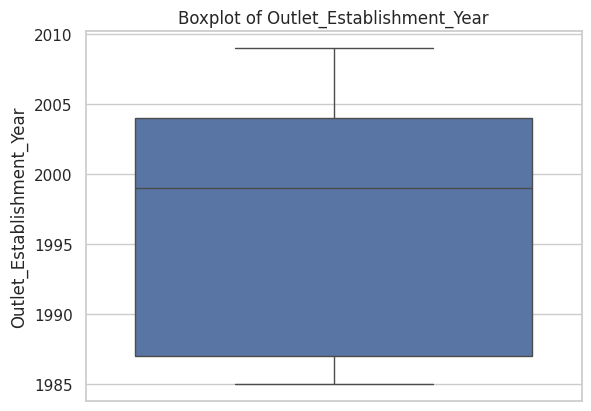

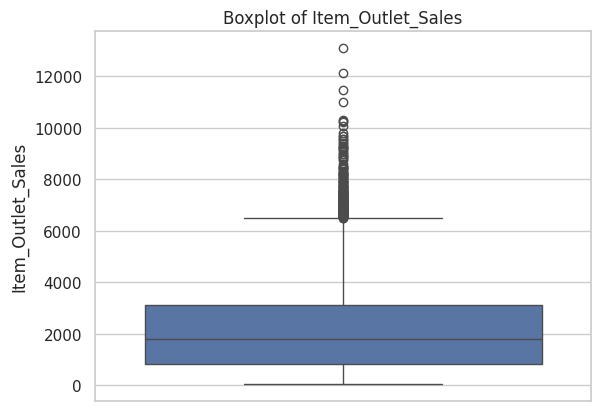

In [15]:
for col in numerical_cols:
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


###Countplots (frequency of categorical features)

/tmp/ipykernel_5744/2186772041.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette="Set2")


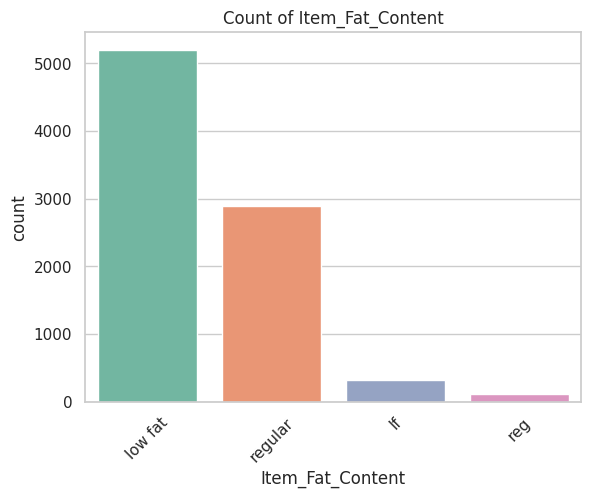

/tmp/ipykernel_5744/2186772041.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette="Set2")


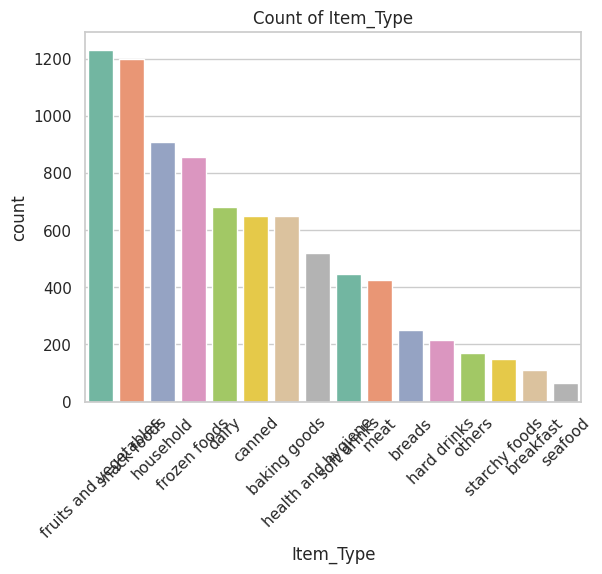

/tmp/ipykernel_5744/2186772041.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette="Set2")


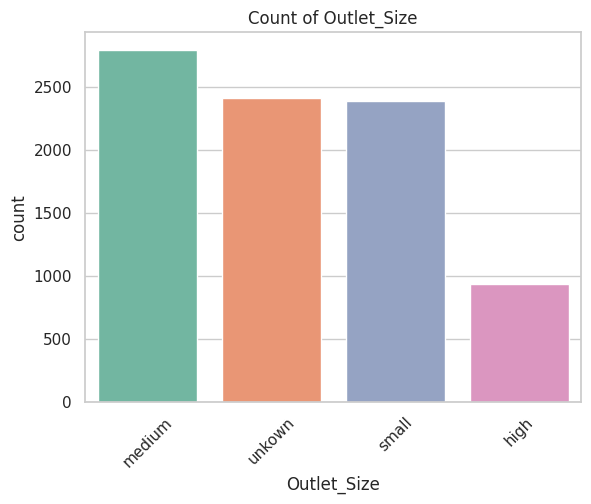

/tmp/ipykernel_5744/2186772041.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette="Set2")


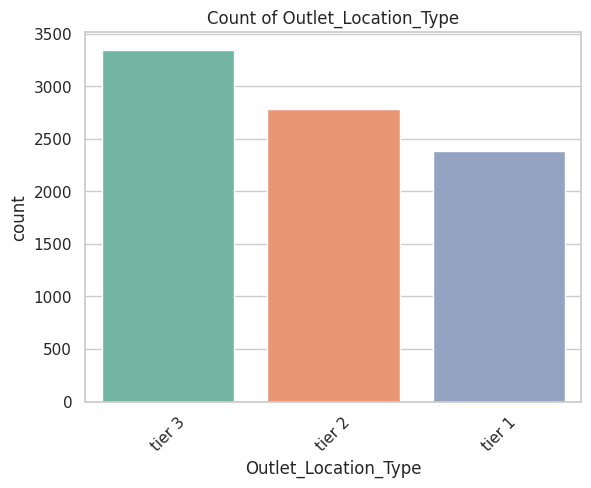

/tmp/ipykernel_5744/2186772041.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette="Set2")


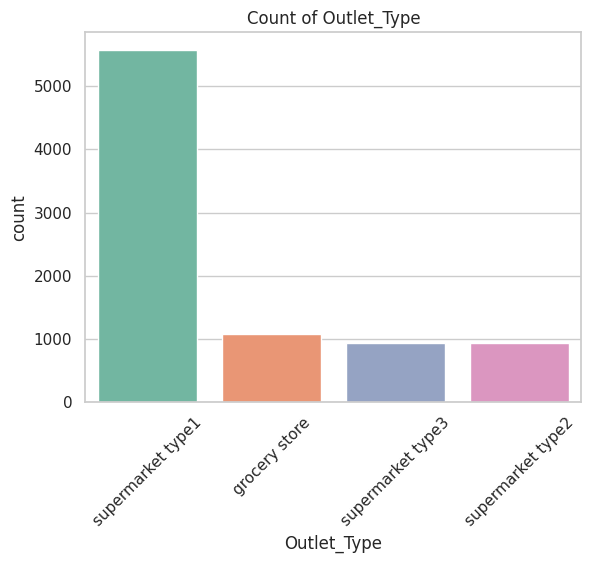

In [16]:
categorical_cols = ["Item_Fat_Content", "Item_Type", "Outlet_Size", "Outlet_Location_Type", "Outlet_Type"]

for col in categorical_cols:
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette="Set2")
    plt.title(f"Count of {col}")
    plt.xticks(rotation=45)
    plt.show()

###Heatmap (correlation between numerical features

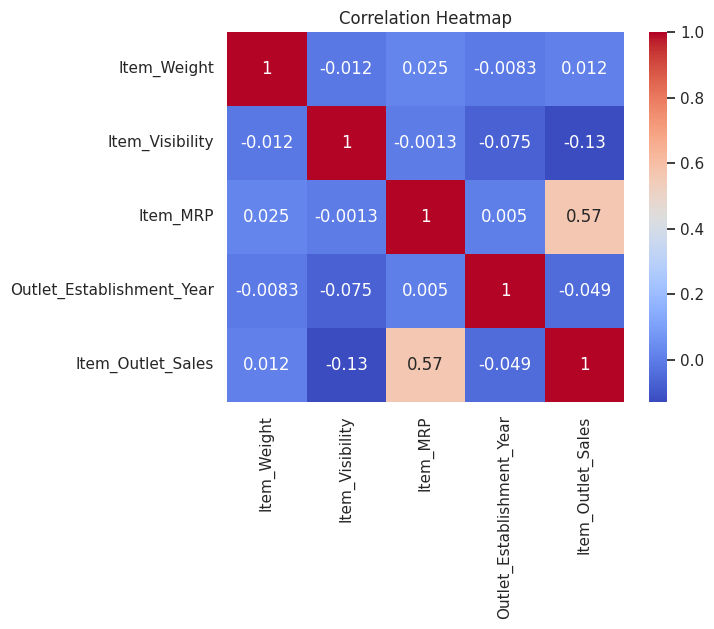

In [17]:
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


## Part 4: Feature Inspection

### Restore Null Values


In [18]:
# Reload the raw data (with original nulls) for Feature Inspection
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('/content/sales_predictions_2023.csv')

print("Null counts after reloading raw data:")
print(df.isnull().sum())
print(f"\nDataset shape: {df.shape}")

Null counts after reloading raw data:
Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

Dataset shape: (8523, 12)


## Feature 1 : item identifier
- it is a unique product id assigned to each item in the store inventory.


/tmp/ipykernel_5744/3686591339.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items.index, y=top_items.values, palette='viridis')


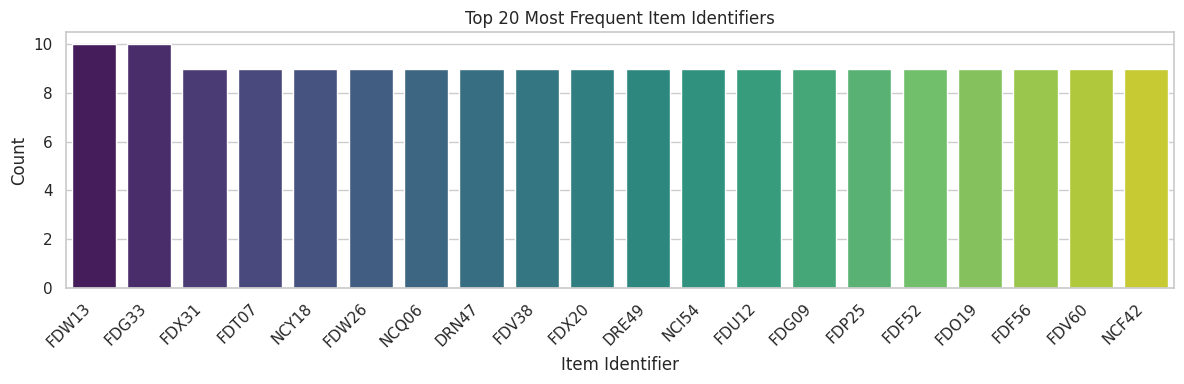

Total unique Item Identifiers: 1559


In [19]:
# top 20 most frequent Item Identifiers (univariate)


top_items = df['Item_Identifier'].value_counts().head(20)
plt.figure(figsize=(12, 4))
sns.barplot(x=top_items.index, y=top_items.values, palette='viridis')
plt.title('Top 20 Most Frequent Item Identifiers')
plt.xlabel('Item Identifier')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(f"Total unique Item Identifiers: {df['Item_Identifier'].nunique()}")

**Feature Inspection (Item_Identifier):**

| Question | Answer |
|---|---|
| **Feature type** | Categorical - Nominal (unique product codes, no order or rank) |
| **Null values** | 0 nulls, No action needed |
| **Constant / quasi-constant?** | No, 1,559 unique values across 8,523 rows |
| **Cardinality** | Very High (1,559 unique IDs)  |
| **Known before target?** | Yes, product identifiers exist before any sale occurs |
| **Business reason to exclude?** | Yes, This is just an ID label with no predictive signal. High cardinality IDs cause overfitting and should be **excluded** from modeling. |

/tmp/ipykernel_5744/3002070541.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_sales.index, y=avg_sales.values, palette='magma')


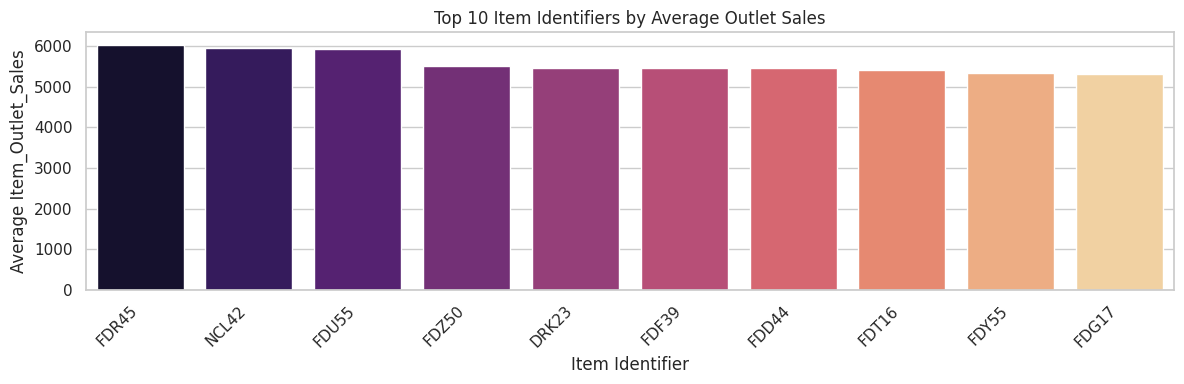

In [20]:
# Multivariate: Item_Identifier vs Item_Outlet_Sales (top 10 by avg sales)
avg_sales = df.groupby('Item_Identifier')['Item_Outlet_Sales'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 4))
sns.barplot(x=avg_sales.index, y=avg_sales.values, palette='magma')
plt.title('Top 10 Item Identifiers by Average Outlet Sales')
plt.xlabel('Item Identifier')
plt.ylabel('Average Item_Outlet_Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Multivariate Analysis (Item_Identifier vs Item_Outlet_Sales:**

| Question | Answer |
|---|---|
| **Expected to be a predictor?** | No, It is a unique ID; it carries no generalized pattern. |
| **Does it appear to be a predictor?** | No, While individual ids may correlate with sales, this is noise, not signal. Including it would cause data leakage or overfitting.|

---
## Feature 2: Item_Weight
The weight of the product (in kilograms). This is a continuous numeric feature.

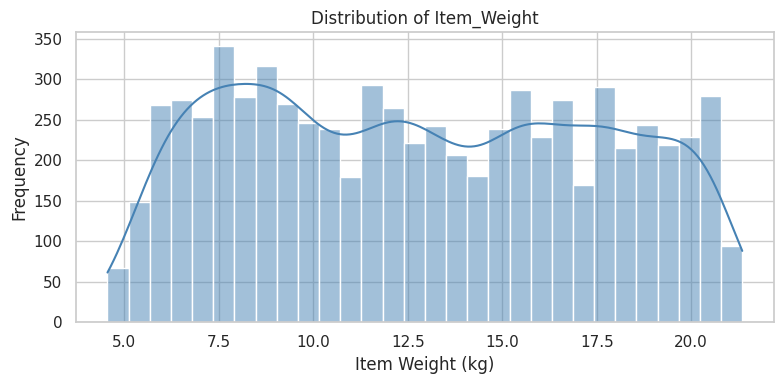

Null count: 1463 (17.2%)
Mean: 12.86, Std: 4.64
Min: 4.55, Max: 21.35


In [21]:
# Univariate: Histogram of Item_Weight
plt.figure(figsize=(8, 4))
sns.histplot(df['Item_Weight'].dropna(), bins=30, kde=True, color='steelblue')
plt.title('Distribution of Item_Weight')
plt.xlabel('Item Weight (kg)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Null count: {df['Item_Weight'].isnull().sum()} ({df['Item_Weight'].isnull().mean()*100:.1f}%)")
print(f"Mean: {df['Item_Weight'].mean():.2f}, Std: {df['Item_Weight'].std():.2f}")
print(f"Min: {df['Item_Weight'].min():.2f}, Max: {df['Item_Weight'].max():.2f}")

**Feature Inspection — Item_Weight:**

| Question | Answer |
|---|---|
| **Feature type** | Numeric — Continuous |
| **Null values** | 1,463 nulls (~17.2%) — **Impute with the mean** (distribution is approximately normal/uniform; mean is a reasonable substitute; dropping rows would lose 17% of data) |
| **Constant / quasi-constant?** | No — ranges from ~4.5 to ~21.4 kg |
| **Cardinality** | N/A (continuous numeric) |
| **Known before target?** | Yes — item weight is a product attribute known before sale |
| **Business reason to exclude?** | No — weight can influence purchase decisions (heavier items may cost more or sell differently) |

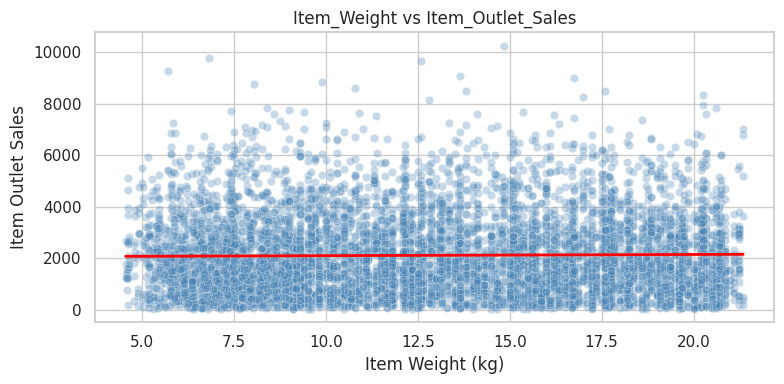

In [22]:
# Multivariate: Item_Weight vs Item_Outlet_Sales (scatter)
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='Item_Weight', y='Item_Outlet_Sales', alpha=0.3, color='steelblue')
sns.regplot(data=df, x='Item_Weight', y='Item_Outlet_Sales', scatter=False, color='red', line_kws={'linewidth':2})
plt.title('Item_Weight vs Item_Outlet_Sales')
plt.xlabel('Item Weight (kg)')
plt.ylabel('Item Outlet Sales')
plt.tight_layout()
plt.show()

**Multivariate Analysis — Item_Weight vs Item_Outlet_Sales:**

| Question | Answer |
|---|---|
| **Expected to be a predictor?** | Possibly — heavier products may be more expensive and sell in different volumes |
| **Does it appear to be a predictor?** | Weak predictor — scatter plot shows little to no clear linear trend. Correlation is near zero. **May retain** for completeness but not a strong feature. |

---
## Feature 3: Item_Fat_Content
Whether the product is categorized as Low Fat or Regular fat content. This is a nominal categorical feature with inconsistent labels in the raw data (e.g., 'LF', 'low fat', 'Low Fat' all mean the same thing).

/tmp/ipykernel_5744/1754745744.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Item_Fat_Content_clean', palette='Set2',


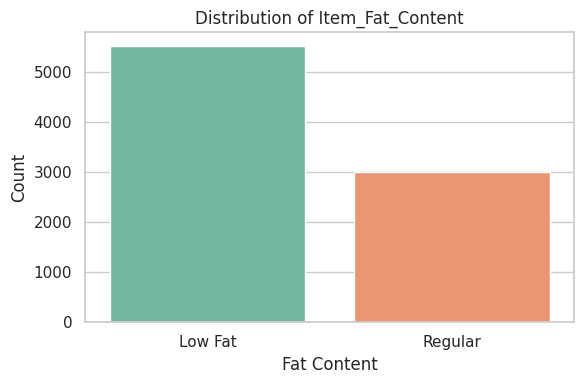

Item_Fat_Content_clean
Low Fat    5517
Regular    3006
Name: count, dtype: int64

Null count: 0


In [23]:
# Fix inconsistent categories first
fat_map = {'low fat': 'Low Fat', 'lf': 'Low Fat', 'reg': 'Regular'}
df['Item_Fat_Content_clean'] = df['Item_Fat_Content'].str.lower().str.strip().replace(fat_map).str.title()

# Univariate: Countplot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Item_Fat_Content_clean', palette='Set2',
              order=df['Item_Fat_Content_clean'].value_counts().index)
plt.title('Distribution of Item_Fat_Content')
plt.xlabel('Fat Content')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(df['Item_Fat_Content_clean'].value_counts())
print(f"\nNull count: {df['Item_Fat_Content'].isnull().sum()}")


**Feature Inspection — Item_Fat_Content:**

| Question | Answer |
|---|---|
| **Feature type** | Categorical — Nominal (Low Fat vs Regular, no rank order) |
| **Null values** | 0 nulls — No action needed |
| **Constant / quasi-constant?** | No — two meaningful categories, though Low Fat dominates (~65%) |
| **Cardinality** | Low (2 after cleaning) — safe for encoding |
| **Known before target?** | Yes — fat content label is set at manufacture |
| **Business reason to exclude?** | No — health-conscious consumers may prefer Low Fat products, which could affect sales |

/tmp/ipykernel_5744/3865598046.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Item_Fat_Content_clean', y='Item_Outlet_Sales', palette='Set2')


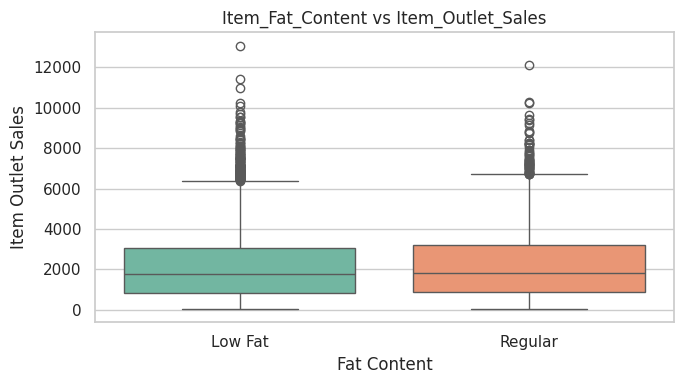

In [24]:
# Multivariate: Item_Fat_Content vs Item_Outlet_Sales (boxplot)
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Item_Fat_Content_clean', y='Item_Outlet_Sales', palette='Set2')
plt.title('Item_Fat_Content vs Item_Outlet_Sales')
plt.xlabel('Fat Content')
plt.ylabel('Item Outlet Sales')
plt.tight_layout()
plt.show()

**Multivariate Analysis — Item_Fat_Content vs Item_Outlet_Sales:**

| Question | Answer |
|---|---|
| **Expected to be a predictor?** | Slightly — health trends might make Low Fat items sell more in certain outlets |
| **Does it appear to be a predictor?** | Weak predictor — boxplots show very similar sales distributions for both categories. **Retain** but don't rely on it heavily. |

---
## Feature 4: Item_Visibility
The percentage of total display area in the store allocated to this product. Ranges from 0 to ~0.33. A value of 0 indicates the product may not be visible on shelves (possibly a data issue).

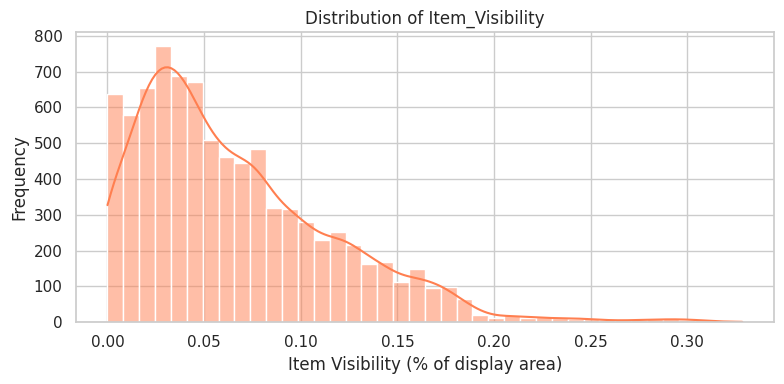

Null count: 0
Zero values: 526 (6.2%)
Mean: 0.0661, Max: 0.3284


In [25]:
# Univariate: Histogram of Item_Visibility
plt.figure(figsize=(8, 4))
sns.histplot(df['Item_Visibility'], bins=40, kde=True, color='coral')
plt.title('Distribution of Item_Visibility')
plt.xlabel('Item Visibility (% of display area)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Null count: {df['Item_Visibility'].isnull().sum()}")
print(f"Zero values: {(df['Item_Visibility'] == 0).sum()} ({(df['Item_Visibility'] == 0).mean()*100:.1f}%)")
print(f"Mean: {df['Item_Visibility'].mean():.4f}, Max: {df['Item_Visibility'].max():.4f}")

**Feature Inspection — Item_Visibility:**

| Question | Answer |
|---|---|
| **Feature type** | Numeric — Continuous |
| **Null values** | 0 nulls — No action needed |
| **Constant / quasi-constant?** | No — values range from 0 to ~0.33 |
| **Cardinality** | N/A (continuous numeric) |
| **Known before target?** | Yes — store display allocation is decided before sales |
| **Business reason to exclude?** | No — visibility directly impacts impulse buying. Note: 0 values may need to be imputed (a product with 0% visibility likely has a data entry error). |

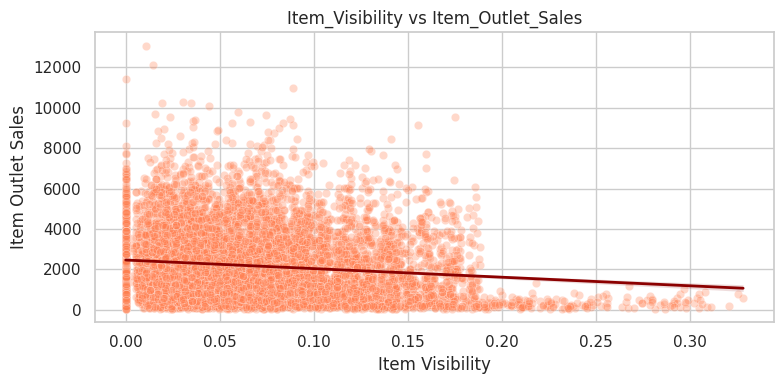

In [26]:
# Multivariate: Item_Visibility vs Item_Outlet_Sales
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='Item_Visibility', y='Item_Outlet_Sales', alpha=0.3, color='coral')
sns.regplot(data=df, x='Item_Visibility', y='Item_Outlet_Sales', scatter=False, color='darkred', line_kws={'linewidth':2})
plt.title('Item_Visibility vs Item_Outlet_Sales')
plt.xlabel('Item Visibility')
plt.ylabel('Item Outlet Sales')
plt.tight_layout()
plt.show()

**Multivariate Analysis — Item_Visibility vs Item_Outlet_Sales:**

| Question | Answer |
|---|---|
| **Expected to be a predictor?** | Yes — more visible items should sell more |
| **Does it appear to be a predictor?** | Surprisingly weak / slightly negative — the regression line is near-flat or slightly negative. This may be due to the 0-value anomalies. **Retain and address zero values during preprocessing.** |

---
## Feature 5: Item_Type
 The category/type of the product (e.g., Dairy, Soft Drinks, Meat, Fruits and Vegetables, Household, etc.). 16 distinct categories. This is a nominal categorical feature.

/tmp/ipykernel_5744/891829061.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Item_Type', order=order, palette='tab20')


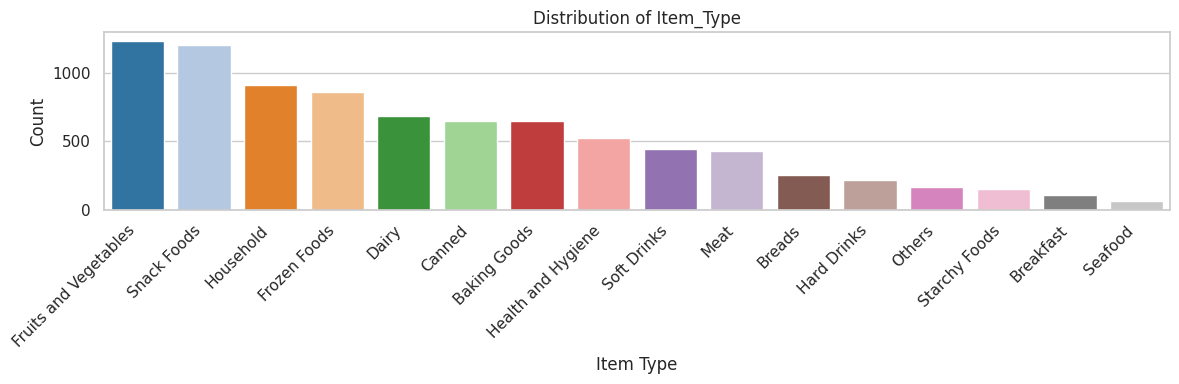

Unique categories: 16
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


In [27]:
# Univariate: Countplot of Item_Type
plt.figure(figsize=(12, 4))
order = df['Item_Type'].value_counts().index
sns.countplot(data=df, x='Item_Type', order=order, palette='tab20')
plt.title('Distribution of Item_Type')
plt.xlabel('Item Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Unique categories: {df['Item_Type'].nunique()}")
print(df['Item_Type'].value_counts())


**Feature Inspection — Item_Type:**

| Question | Answer |
|---|---|
| **Feature type** | Categorical — Nominal (product category names, no order) |
| **Null values** | 0 nulls — No action needed |
| **Constant / quasi-constant?** | No — 16 categories with varied frequencies |
| **Cardinality** | Medium (16 categories) — manageable with one-hot encoding |
| **Known before target?** | Yes — product type is known before the sale |
| **Business reason to exclude?** | No — product type strongly influences consumer demand (e.g., staples like Fruits & Vegetables sell more than Seafood) |

/tmp/ipykernel_5744/1767006615.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Item_Type', y='Item_Outlet_Sales', order=order, palette='tab20')


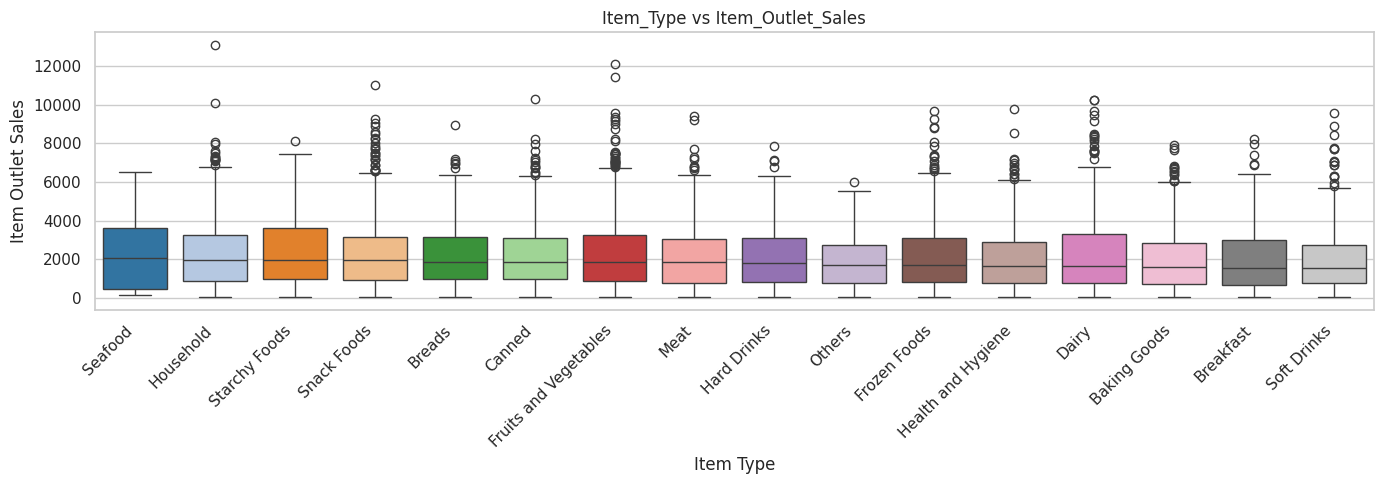

In [28]:
# Multivariate: Item_Type vs Item_Outlet_Sales (boxplot)
plt.figure(figsize=(14, 5))
order = df.groupby('Item_Type')['Item_Outlet_Sales'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Item_Type', y='Item_Outlet_Sales', order=order, palette='tab20')
plt.title('Item_Type vs Item_Outlet_Sales')
plt.xlabel('Item Type')
plt.ylabel('Item Outlet Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Multivariate Analysis — Item_Type vs Item_Outlet_Sales:**

| Question | Answer |
|---|---|
| **Expected to be a predictor?** | Yes — different product categories have different demand levels |
| **Does it appear to be a predictor?** | Yes — there is visible variation in median sales across item types. Some categories (e.g., Starchy Foods, Seafood) show higher medians than others. **Include in the model.** |

---
## Feature 6: Item_MRP
Maximum Retail Price (list price) of the product. This is a continuous numeric feature.

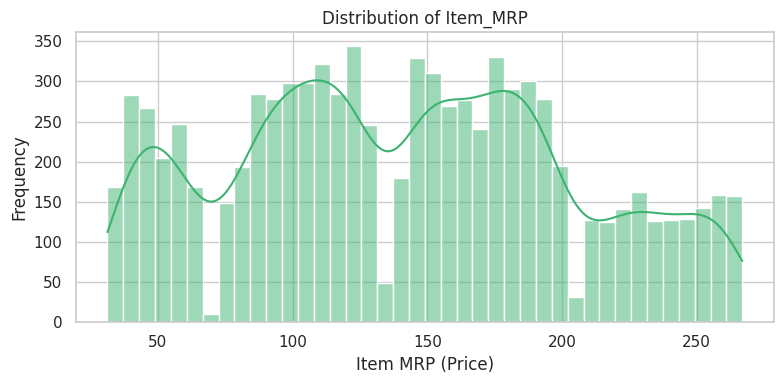

Null count: 0
Mean: 140.99, Std: 62.28
Min: 31.29, Max: 266.89


In [29]:
# Univariate: Histogram of Item_MRP
plt.figure(figsize=(8, 4))
sns.histplot(df['Item_MRP'], bins=40, kde=True, color='mediumseagreen')
plt.title('Distribution of Item_MRP')
plt.xlabel('Item MRP (Price)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Null count: {df['Item_MRP'].isnull().sum()}")
print(f"Mean: {df['Item_MRP'].mean():.2f}, Std: {df['Item_MRP'].std():.2f}")
print(f"Min: {df['Item_MRP'].min():.2f}, Max: {df['Item_MRP'].max():.2f}")

**Feature Inspection — Item_MRP:**

| Question | Answer |
|---|---|
| **Feature type** | Numeric — Continuous |
| **Null values** | 0 nulls — No action needed |
| **Constant / quasi-constant?** | No — wide range from ~31 to ~267 |
| **Cardinality** | N/A (continuous numeric) |
| **Known before target?** | Yes — MRP is set before products are sold |
| **Business reason to exclude?** | No — price is a fundamental driver of sales revenue |

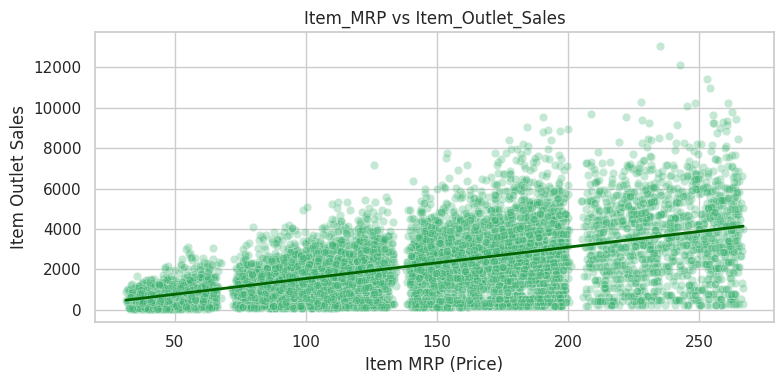

Pearson correlation with Item_Outlet_Sales: 0.568


In [30]:
# Multivariate: Item_MRP vs Item_Outlet_Sales (scatter)
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='Item_MRP', y='Item_Outlet_Sales', alpha=0.3, color='mediumseagreen')
sns.regplot(data=df, x='Item_MRP', y='Item_Outlet_Sales', scatter=False, color='darkgreen', line_kws={'linewidth':2})
plt.title('Item_MRP vs Item_Outlet_Sales')
plt.xlabel('Item MRP (Price)')
plt.ylabel('Item Outlet Sales')
plt.tight_layout()
plt.show()

corr = df['Item_MRP'].corr(df['Item_Outlet_Sales'])
print(f"Pearson correlation with Item_Outlet_Sales: {corr:.3f}")

**Multivariate Analysis — Item_MRP vs Item_Outlet_Sales:**

| Question | Answer |
|---|---|
| **Expected to be a predictor?** | Yes — higher-priced items generate higher revenue per unit |
| **Does it appear to be a predictor?** | **Yes — strongest numeric predictor.** Clear positive linear relationship (correlation ≈ +0.57). Higher MRP → higher sales. **Definitely include in the model.** |

---
## Feature 7: Outlet_Identifier
Unique store/outlet ID (e.g., OUT049, OUT018). This is a nominal identifier for each retail outlet.

/tmp/ipykernel_5744/3079358323.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Outlet_Identifier',


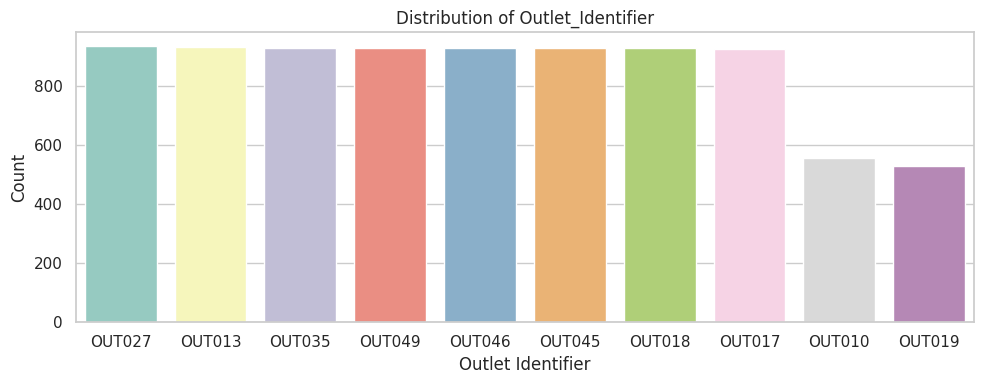

Unique outlets: 10
Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Name: count, dtype: int64


In [31]:
# Univariate: Countplot of Outlet_Identifier
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='Outlet_Identifier',
              order=df['Outlet_Identifier'].value_counts().index, palette='Set3')
plt.title('Distribution of Outlet_Identifier')
plt.xlabel('Outlet Identifier')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Unique outlets: {df['Outlet_Identifier'].nunique()}")
print(df['Outlet_Identifier'].value_counts())

**Feature Inspection — Outlet_Identifier:**

| Question | Answer |
|---|---|
| **Feature type** | Categorical — Nominal (store codes, no order) |
| **Null values** | 0 nulls — No action needed |
| **Constant / quasi-constant?** | No — 10 distinct outlets, some with different item counts |
| **Cardinality** | Low-Medium (10) — manageable |
| **Known before target?** | Yes — outlet ID is a fixed attribute |
| **Business reason to exclude?** | Potentially — it's an ID that captures outlet-specific effects already represented by Outlet_Type, Outlet_Size, etc. However, it may encode unique outlet-level variance not captured by other features. **Consider excluding** if other outlet features are present, to avoid redundancy. |

/tmp/ipykernel_5744/3648974798.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outlet_Identifier', y='Item_Outlet_Sales', order=order, palette='Set3')


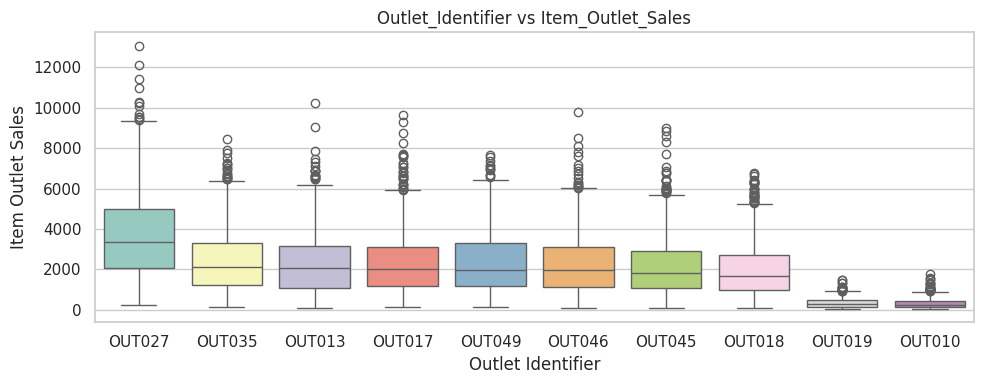

In [32]:
# Multivariate: Outlet_Identifier vs Item_Outlet_Sales
plt.figure(figsize=(10, 4))
order = df.groupby('Outlet_Identifier')['Item_Outlet_Sales'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Outlet_Identifier', y='Item_Outlet_Sales', order=order, palette='Set3')
plt.title('Outlet_Identifier vs Item_Outlet_Sales')
plt.xlabel('Outlet Identifier')
plt.ylabel('Item Outlet Sales')
plt.tight_layout()
plt.show()

**Multivariate Analysis — Outlet_Identifier vs Item_Outlet_Sales:**

| Question | Answer |
|---|---|
| **Expected to be a predictor?** | Possibly — different stores may have different foot traffic and sales |
| **Does it appear to be a predictor?** | Yes — clear differences in sales distributions across outlets (e.g., OUT010 and OUT019 appear lower). However, since these are IDs, **consider using other outlet attributes instead** to avoid overfitting to specific store IDs. |

---
## Feature 8: Outlet_Establishment_Year
The year the outlet/store was established. This is a discrete numeric (or ordinal) feature. Older outlets may have more loyal customer bases.

/tmp/ipykernel_5744/1875249975.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Outlet_Establishment_Year',


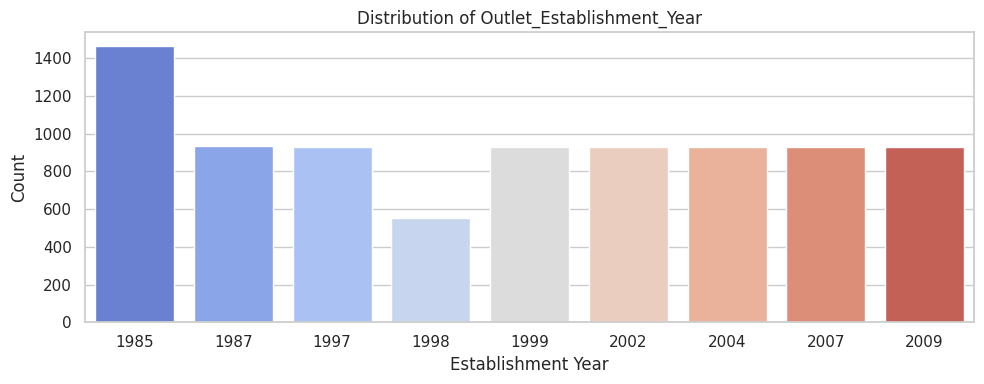

Unique years: [np.int64(1985), np.int64(1987), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2002), np.int64(2004), np.int64(2007), np.int64(2009)]
Null count: 0


In [33]:
# Univariate: Countplot of Outlet_Establishment_Year
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='Outlet_Establishment_Year',
              order=sorted(df['Outlet_Establishment_Year'].unique()), palette='coolwarm')
plt.title('Distribution of Outlet_Establishment_Year')
plt.xlabel('Establishment Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Unique years: {sorted(df['Outlet_Establishment_Year'].unique())}")
print(f"Null count: {df['Outlet_Establishment_Year'].isnull().sum()}")

**Feature Inspection — Outlet_Establishment_Year:**

| Question | Answer |
|---|---|
| **Feature type** | Numeric — Discrete (years) / could be treated as ordinal |
| **Null values** | 0 nulls — No action needed |
| **Constant / quasi-constant?** | No — 9 distinct years (1985–2009) |
| **Cardinality** | Low (9 values) |
| **Known before target?** | Yes — the founding year is historical and fixed |
| **Business reason to exclude?** | No — **but consider engineering it** into "Outlet Age" (2023 − year) which is more interpretable and linear for models |

/tmp/ipykernel_5744/2141133132.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outlet_Establishment_Year', y='Item_Outlet_Sales', order=order, palette='coolwarm')


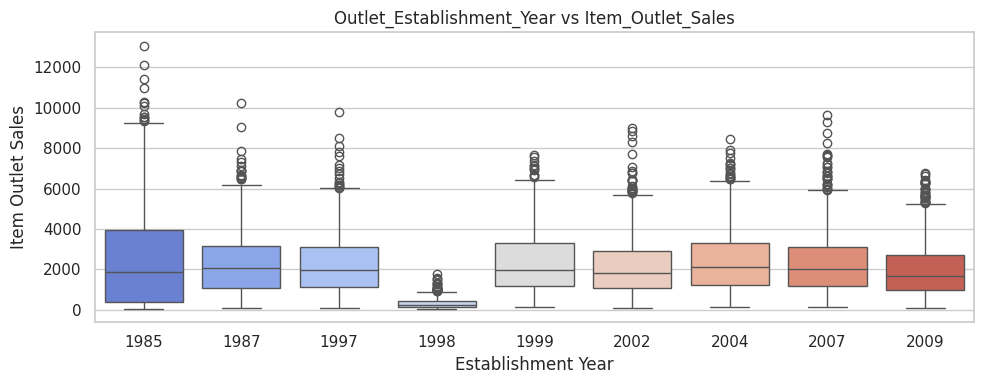

In [34]:
# Engineer Outlet_Age for better interpretability
df['Outlet_Age'] = 2023 - df['Outlet_Establishment_Year']

# Multivariate: Outlet_Establishment_Year vs Item_Outlet_Sales
plt.figure(figsize=(10, 4))
order = sorted(df['Outlet_Establishment_Year'].unique())
sns.boxplot(data=df, x='Outlet_Establishment_Year', y='Item_Outlet_Sales', order=order, palette='coolwarm')
plt.title('Outlet_Establishment_Year vs Item_Outlet_Sales')
plt.xlabel('Establishment Year')
plt.ylabel('Item Outlet Sales')
plt.tight_layout()
plt.show()

**Multivariate Analysis — Outlet_Establishment_Year vs Item_Outlet_Sales:**

| Question | Answer |
|---|---|
| **Expected to be a predictor?** | Yes — older outlets may have more established customer bases |
| **Does it appear to be a predictor?** | Partially — the 1998 outlet shows notably lower median sales. **Retain, but engineer into Outlet_Age** for better model performance. |

---
## Feature 9: Outlet_Size
The physical size of the store: Small, Medium, or High. This is an ordinal categorical feature (there is a meaningful order: Small < Medium < High).

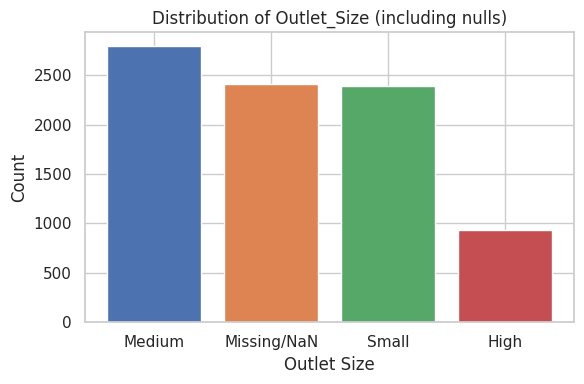

Null count: 2410 (28.3%)
Outlet_Size
Medium    2793
NaN       2410
Small     2388
High       932
Name: count, dtype: int64


In [35]:
# Univariate: Countplot of Outlet_Size (including NaN)
plt.figure(figsize=(6, 4))
size_counts = df['Outlet_Size'].value_counts(dropna=False)
size_labels = [str(x) if pd.notna(x) else 'Missing/NaN' for x in size_counts.index]
plt.bar(size_labels, size_counts.values, color=['#4c72b0','#dd8452','#55a868','#c44e52'])
plt.title('Distribution of Outlet_Size (including nulls)')
plt.xlabel('Outlet Size')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

null_pct = df['Outlet_Size'].isnull().mean() * 100
print(f"Null count: {df['Outlet_Size'].isnull().sum()} ({null_pct:.1f}%)")
print(df['Outlet_Size'].value_counts(dropna=False))

**Feature Inspection — Outlet_Size:**

| Question | Answer |
|---|---|
| **Feature type** | Categorical — Ordinal (Small < Medium < High) |
| **Null values** | **2,410 nulls (~28.3%)** — High missing rate. **Do NOT drop rows** (would lose 28% of data). **Impute with mode** ("Medium") or create a separate "Unknown" category, or use outlet type to infer size. |
| **Constant / quasi-constant?** | No — three size categories |
| **Cardinality** | Low (3) |
| **Known before target?** | Yes — physical store size is a fixed property |
| **Business reason to exclude?** | No — larger stores likely carry more products and attract more customers, which should drive higher sales |

/tmp/ipykernel_5744/790643987.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outlet_Size', y='Item_Outlet_Sales', order=order, palette='Blues')


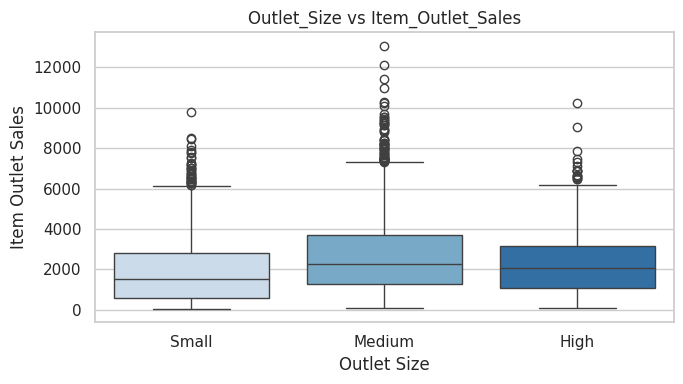

In [36]:
# Multivariate: Outlet_Size vs Item_Outlet_Sales (boxplot)
plt.figure(figsize=(7, 4))
order = ['Small', 'Medium', 'High']
sns.boxplot(data=df, x='Outlet_Size', y='Item_Outlet_Sales', order=order, palette='Blues')
plt.title('Outlet_Size vs Item_Outlet_Sales')
plt.xlabel('Outlet Size')
plt.ylabel('Item Outlet Sales')
plt.tight_layout()
plt.show()

**Multivariate Analysis — Outlet_Size vs Item_Outlet_Sales:**

| Question | Answer |
|---|---|
| **Expected to be a predictor?** | Yes — bigger stores have more shelf space and customers |
| **Does it appear to be a predictor?** | Yes — Medium and High outlets tend to have higher sales than Small outlets. **Retain and impute missing values** before modeling. |

---
## Feature 10: Outlet_Location_Type
The type of city/area where the outlet is located: Tier 1 (major metro), Tier 2 (mid-size city), or Tier 3 (small town/rural). This is an ordinal categorical feature.

/tmp/ipykernel_5744/590739461.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Outlet_Location_Type',


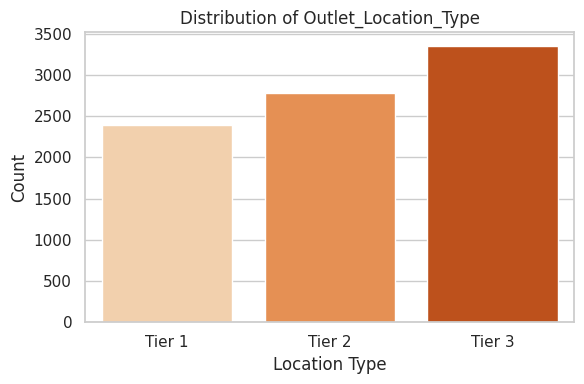

Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64

Null count: 0


In [37]:
# Univariate: Countplot of Outlet_Location_Type
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Outlet_Location_Type',
              order=['Tier 1','Tier 2','Tier 3'], palette='Oranges')
plt.title('Distribution of Outlet_Location_Type')
plt.xlabel('Location Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(df['Outlet_Location_Type'].value_counts())
print(f"\nNull count: {df['Outlet_Location_Type'].isnull().sum()}")

**Feature Inspection — Outlet_Location_Type:**

| Question | Answer |
|---|---|
| **Feature type** | Categorical — Ordinal (Tier 1 > Tier 2 > Tier 3 by city size) |
| **Null values** | 0 nulls — No action needed |
| **Constant / quasi-constant?** | No — balanced across three tiers |
| **Cardinality** | Low (3) — easy to encode |
| **Known before target?** | Yes — location is a fixed store attribute |
| **Business reason to exclude?** | No — urban vs rural location strongly affects foot traffic and purchasing power |

/tmp/ipykernel_5744/1690334905.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outlet_Location_Type', y='Item_Outlet_Sales',


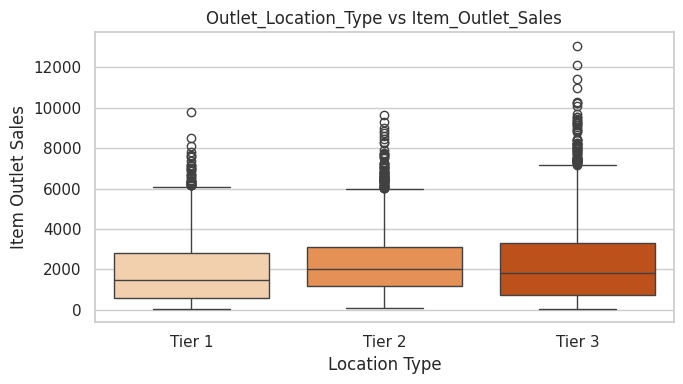

In [38]:
# Multivariate: Outlet_Location_Type vs Item_Outlet_Sales
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Outlet_Location_Type', y='Item_Outlet_Sales',
            order=['Tier 1','Tier 2','Tier 3'], palette='Oranges')
plt.title('Outlet_Location_Type vs Item_Outlet_Sales')
plt.xlabel('Location Type')
plt.ylabel('Item Outlet Sales')
plt.tight_layout()
plt.show()

**Multivariate Analysis — Outlet_Location_Type vs Item_Outlet_Sales:**

| Question | Answer |
|---|---|
| **Expected to be a predictor?** | Yes — Tier 1 cities have higher purchasing power |
| **Does it appear to be a predictor?** | Moderate — Tier 3 locations show slightly lower median sales. The differences are present but not dramatic. **Include in the model.** |

---
## Feature 11: Outlet_Type
The type of outlet: Grocery Store, Supermarket Type1, Supermarket Type2, or Supermarket Type3. This is a nominal categorical feature (Supermarket types differ in size and product variety).

/tmp/ipykernel_5744/1484348996.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Outlet_Type',


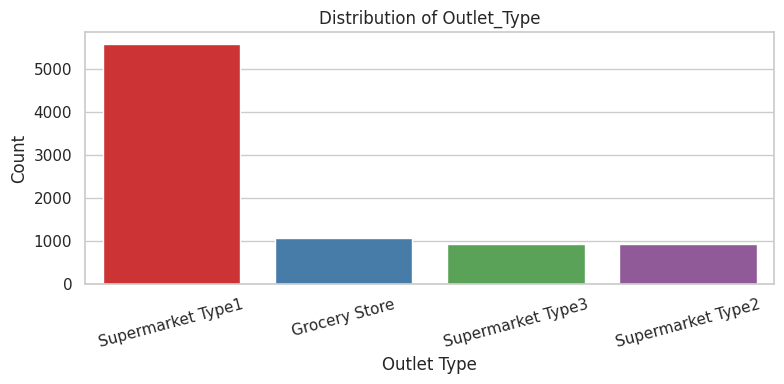

Outlet_Type
Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
Name: count, dtype: int64

Null count: 0


In [39]:
# Univariate: Countplot of Outlet_Type
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Outlet_Type',
              order=df['Outlet_Type'].value_counts().index, palette='Set1')
plt.title('Distribution of Outlet_Type')
plt.xlabel('Outlet Type')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(df['Outlet_Type'].value_counts())
print(f"\nNull count: {df['Outlet_Type'].isnull().sum()}")

**Feature Inspection — Outlet_Type:**

| Question | Answer |
|---|---|
| **Feature type** | Categorical — Nominal (store format categories) |
| **Null values** | 0 nulls — No action needed |
| **Constant / quasi-constant?** | No — 4 distinct types; Supermarket Type1 dominates |
| **Cardinality** | Low (4) — easy to one-hot encode |
| **Known before target?** | Yes — outlet type is a fixed store attribute |
| **Business reason to exclude?** | No — supermarkets and grocery stores have fundamentally different sales volumes and product ranges |

/tmp/ipykernel_5744/4189039657.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outlet_Type', y='Item_Outlet_Sales', order=order, palette='Set1')


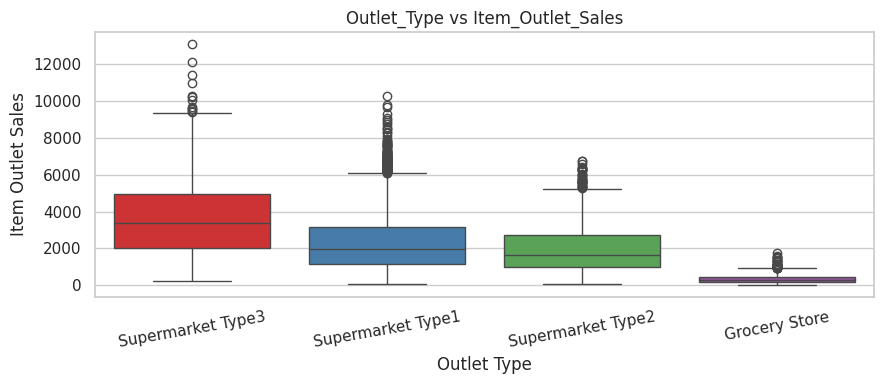

In [40]:
# Multivariate: Outlet_Type vs Item_Outlet_Sales
plt.figure(figsize=(9, 4))
order = df.groupby('Outlet_Type')['Item_Outlet_Sales'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Outlet_Type', y='Item_Outlet_Sales', order=order, palette='Set1')
plt.title('Outlet_Type vs Item_Outlet_Sales')
plt.xlabel('Outlet Type')
plt.ylabel('Item Outlet Sales')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

**Multivariate Analysis — Outlet_Type vs Item_Outlet_Sales:**

| Question | Answer |
|---|---|
| **Expected to be a predictor?** | Yes — supermarkets handle far more volume than grocery stores |
| **Does it appear to be a predictor?** | **Yes — one of the strongest predictors.** Grocery Stores show significantly lower sales; Supermarket Type3 shows the highest. **Definitely include in the model.** |

---
## Feature Inspection Summary

| Feature | Type | Nulls | Action on Nulls | Include in Model? | Strength as Predictor |
|---|---|---|---|---|---|
| Item_Identifier | Nominal | 0 | — |  Exclude | None (ID) |
| Item_Weight | Numeric | 1,463 (17.2%) | Impute with mean |  Include | Weak |
| Item_Fat_Content | Nominal | 0 | Clean categories |  Include | Weak |
| Item_Visibility | Numeric | 0 | Fix 0-value entries |  Include | Weak-Moderate |
| Item_Type | Nominal | 0 | — |  Include | Moderate |
| Item_MRP | Numeric | 0 | — |  Include | Strong|
| Outlet_Identifier | Nominal | 0 | — |  Optional | Moderate (captured by other features) |
| Outlet_Establishment_Year | Numeric | 0 | Engineer to Age |  Include | Moderate |
| Outlet_Size | Ordinal | 2,410 (28.3%) | Impute with mode or "Unknown" |  Include | Moderate |
| Outlet_Location_Type | Ordinal | 0 | — |  Include | Moderate |
| Outlet_Type | Nominal | 0 | — |  Include | Strong |